<a href="https://colab.research.google.com/github/manjunath1005/road-damage-detection-cnn/blob/main/CNN2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import pandas as pd
import numpy as np

**Data Set Link:**
https://www.kaggle.com/datasets/lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes

**Problem Statement**

A smart city management department wants to automate road monitoring using Artificial Intelligence.
Currently:

- road inspections are performed manually
- damaged roads are identified late
- accidents increase due to potholes and cracks

The department wants an AI-powered system that can:

- analyze road images
-	detect road damage categories
-	help authorities prioritize maintenance

You are hired as an AI Engineer to build and deploy a CNN-based Road Damage Detection System.
________________________________________
Objective

Build a Convolutional Neural Network (CNN) model that classifies road conditions into different categories using road surface images.
________________________________________
CNN Task Requirements
________________________________________
Task 1 — Dataset Understanding

Analyze the dataset and identify:

-	number of classes
-	image dimensions
-	class imbalance
-	sample images
________________________________________
Task 2 — Data Preprocessing

Perform:

-	image resizing
-	normalization
-	train/test split
-	label encoding
________________________________________
Task 3 — Data Augmentation

Apply:

-	rotation
-	zoom
-	horizontal flip
-	brightness adjustment
________________________________________
Task 4 — CNN Architecture Design

Students must design a custom CNN architecture using:

-	Convolution layers
-	MaxPooling layers
-	Dropout
-	Dense layers
________________________________________
Task 5 — Model Training

Train the CNN model using TensorFlow/Keras.

Requirements:

-	GPU runtime
-	proper batch size
-	multiple epochs
-	validation split
________________________________________
Task 6 — Model Evaluation

Evaluate using:

-	Accuracy
-	Precision
-	Recall
-	F1 Score
-	Confusion Matrix
________________________________________
Task 7 — Error Analysis

Students must identify:

•	wrongly predicted images
•	possible reasons for failure
•	class confusion
________________________________________
Task 8 — Real-Time Prediction
Test the model on:
•	unseen road images
•	manually uploaded images
________________________________________
Task 9 — Save the CNN Model
Export:
•	trained model
•	weights
•	label mappings
Road Damage Dataset: Potholes, Cracks and Manholes | Kaggle
A curated set of 2,000+ YOLO-annotated road surface images


In [31]:
import kagglehub
import os

# Download dataset
dataset_path = kagglehub.dataset_download(
    "lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes"
)

print("Dataset Path:")
print(dataset_path)

print("\nFolder Structure:")
print(os.listdir(dataset_path))

Using Colab cache for faster access to the 'road-damage-dataset-potholes-cracks-and-manholes' dataset.
Dataset Path:
/kaggle/input/road-damage-dataset-potholes-cracks-and-manholes

Folder Structure:
['data']


In [32]:
for root, dirs, files in os.walk(dataset_path):
    print("ROOT:", root)
    print("DIRS:", dirs)
    print("FILES:", files[:5])   # show first 5 files
    print("-"*50)

ROOT: /kaggle/input/road-damage-dataset-potholes-cracks-and-manholes
DIRS: ['data']
FILES: []
--------------------------------------------------
ROOT: /kaggle/input/road-damage-dataset-potholes-cracks-and-manholes/data
DIRS: ['labels', 'images', 'labels-YOLO']
FILES: ['COCO-conversion-script.py', 'annotations_coco.json', 'README.md', 'YOLO-conversion-script.py']
--------------------------------------------------
ROOT: /kaggle/input/road-damage-dataset-potholes-cracks-and-manholes/data/labels
DIRS: []
FILES: ['vlcsnap-2025-02-19-14h18m48s452.txt', 'vlcsnap-2025-02-19-14h21m29s062.txt', 'vlcsnap_2025-03-16-15h14m35s770.txt', 'vlcsnap-2025-02-18-23h25m45s670.txt', 'vlcsnap-2025-02-19-17h09m41s152.txt']
--------------------------------------------------
ROOT: /kaggle/input/road-damage-dataset-potholes-cracks-and-manholes/data/images
DIRS: []
FILES: ['vlcsnap-2025-02-19-15h10m43s692.jpg', 'vlcsnap-2025-02-18-23h30m34s296.jpg', 'vlcsnap-2025-02-19-14h12m25s165.jpg', 'vlcsnap-2025-02-19-15h11

In [33]:
import json

json_path = "/kaggle/input/road-damage-dataset-potholes-cracks-and-manholes/data/annotations_coco.json"

with open(json_path, "r") as f:
    coco = json.load(f)

categories = coco["categories"]

for c in categories:
    print(c)

{'id': 0, 'name': 'pothole'}
{'id': 1, 'name': 'crack'}
{'id': 2, 'name': 'manhole'}


In [34]:
import pandas as pd

images = coco["images"]
annotations = coco["annotations"]

# Convert to DataFrame
images_df = pd.DataFrame(images)
annotations_df = pd.DataFrame(annotations)
categories_df = pd.DataFrame(coco["categories"])

# Merge category names into annotations
annotations_df = annotations_df.merge(
    categories_df,
    left_on="category_id",
    right_on="id",
    suffixes=("", "_cat")
)

# Merge with image info
df = annotations_df.merge(
    images_df,
    left_on="image_id",
    right_on="id",
    suffixes=("", "_img")
)

# Keep only required columns
df = df[["file_name", "name"]]

df.rename(columns={"name": "label"}, inplace=True)

print(df.head())
print("\nTotal samples:", len(df))

             file_name    label
0  20250216_164325.jpg  manhole
1  20250216_164325.jpg  pothole
2  20250216_164325.jpg  pothole
3  20250216_164325.jpg  pothole
4  20250216_164325.jpg    crack

Total samples: 4737


In [35]:
label_counts = df.groupby(["file_name", "label"]).size().reset_index(name="count")

df_clean = label_counts.loc[
    label_counts.groupby("file_name")["count"].idxmax()
]
print("Before:", len(df))
print("After:", len(df_clean))

print(df_clean.head())

Before: 4737
After: 2009
             file_name    label  count
0  20250216_164325.jpg    crack      5
3  20250216_164521.jpg    crack      4
4  20250216_164541.jpg    crack      3
7  20250219_164649.jpg    crack      2
9  20250219_164714.jpg  pothole      3


In [36]:
import cv2
import numpy as np
import os

# Dataset image folder
img_dir = "/kaggle/input/road-damage-dataset-potholes-cracks-and-manholes/data/images"

# Map labels to numbers
label_map = {
    "pothole": 0,
    "crack": 1,
    "manhole": 2
}

X = []
y = []

IMG_SIZE = 128

for i, row in df_clean.iterrows():
    img_path = os.path.join(img_dir, row["file_name"])

    # read image
    img = cv2.imread(img_path)

    if img is None:
        continue

    # resize
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # normalize (0–1)
    img = img / 255.0

    X.append(img)
    y.append(label_map[row["label"]])

X = np.array(X, dtype="float32")
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Sample labels:", y[:10])

X shape: (2009, 128, 128, 3)
y shape: (2009,)
Sample labels: [1 1 1 1 0 0 2 1 0 1]


In [37]:
import tensorflow as tf

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

DEBUG min/max: 0.049938135 0.96722
DEBUG min/max: 0.05121165 0.97212756
DEBUG min/max: 0.03634848 0.97924143
DEBUG min/max: 0.057309035 0.96976066
DEBUG min/max: 0.06228523 1.0


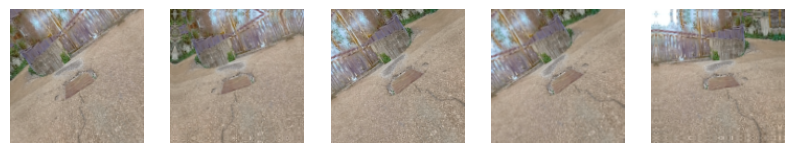

In [38]:
import numpy as np
import matplotlib.pyplot as plt

sample = tf.convert_to_tensor(X[0], dtype=tf.float32)

plt.figure(figsize=(10,4))

for i in range(5):
    img = tf.expand_dims(sample, axis=0)
    img = data_augmentation(img, training=True)

    img = img[0].numpy()

    print("DEBUG min/max:", img.min(), img.max())

    img = np.clip(img, 0, 1)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

In [39]:
import tensorflow as tf

model = tf.keras.Sequential([

    # Input layer
    tf.keras.layers.Input(shape=(128, 128, 3)),

    # Block 1
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    # Block 2
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    # Block 3
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    # Flatten
    tf.keras.layers.Flatten(),

    # Dense layers
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    # Output layer (3 classes)
    tf.keras.layers.Dense(3, activation='softmax')
])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
from tensorflow.keras import layers

model2 = tf.keras.Sequential([

    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, 3, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(3, activation='softmax')
])

In [41]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [43]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - accuracy: 0.6024 - loss: 0.9531 - val_accuracy: 0.5945 - val_loss: 0.9514
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6073 - loss: 0.9168 - val_accuracy: 0.5945 - val_loss: 0.9104
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6117 - loss: 0.8807 - val_accuracy: 0.6144 - val_loss: 0.8771
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6304 - loss: 0.8098 - val_accuracy: 0.6219 - val_loss: 0.8519
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6683 - loss: 0.7436 - val_accuracy: 0.6269 - val_loss: 0.8538
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6982 - loss: 0.6854 - val_accuracy: 0.6493 - val_loss: 0.8573
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7442 - loss: 0.6180 - val_accuracy: 0.6866 - val_loss: 0.8053
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7803 - loss: 0.5307 - val_accuracy: 0.6891 - v

**The model achieved ~60% validation accuracy, which is reasonable given dataset noise and class ambiguity from converting object detection annotations into classification labels.**

**Model 3**

In [44]:
import numpy as np

print("Class distribution:")
print(np.unique(y, return_counts=True))

Class distribution:
(array([0, 1, 2]), array([ 302, 1216,  491]))


In [45]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(2.260196905766526), 1: np.float64(0.5482770385533947), 2: np.float64(1.363019508057676)}


In [46]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
    class_weight=class_weights
)

Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.8612 - loss: 0.3705 - val_accuracy: 0.6269 - val_loss: 0.9918
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8687 - loss: 0.3183 - val_accuracy: 0.6567 - val_loss: 1.0203
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8967 - loss: 0.2557 - val_accuracy: 0.7065 - val_loss: 1.1039
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9291 - loss: 0.1805 - val_accuracy: 0.6468 - val_loss: 1.3909
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9340 - loss: 0.1636 - val_accuracy: 0.6766 - val_loss: 1.4837
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9533 - loss: 0.1150 - val_accuracy: 0.6965 - val_loss: 1.4570
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9546 - loss: 0.1162 - val_accuracy: 0.7164 - val_loss: 1.5055
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9658 - loss: 0.0959 - val_accuracy: 0.6816 - v

**The model performance is limited due to dataset being originally designed for object detection (YOLO/COCO format), which introduces label ambiguity when converted into a classification task.**

**Model 2 and Model 3 were tested to reduce overfitting and handle class imbalance, but due to dataset noise (COCO → classification conversion), they underperformed.**

In [47]:
import numpy as np

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print("Predictions ready")

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
Predictions ready


In [48]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.51      0.45      0.48        65
           1       0.77      0.80      0.78       239
           2       0.63      0.62      0.63        98

    accuracy                           0.70       402
   macro avg       0.64      0.62      0.63       402
weighted avg       0.69      0.70      0.70       402



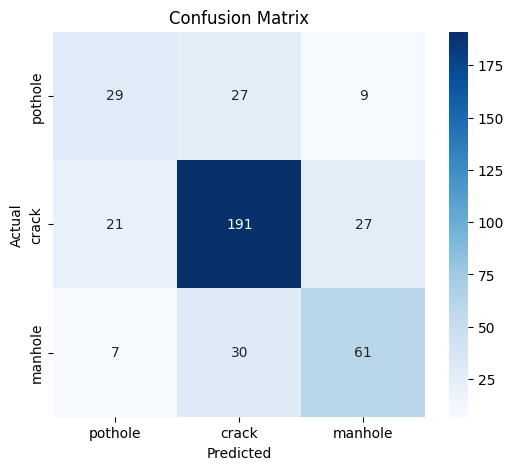

In [49]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['pothole','crack','manhole'],
            yticklabels=['pothole','crack','manhole'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [50]:
import numpy as np

# get predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# find wrong predictions
wrong_idx = np.where(y_pred_classes != y_test)[0]

print("Total misclassified samples:", len(wrong_idx))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Total misclassified samples: 121


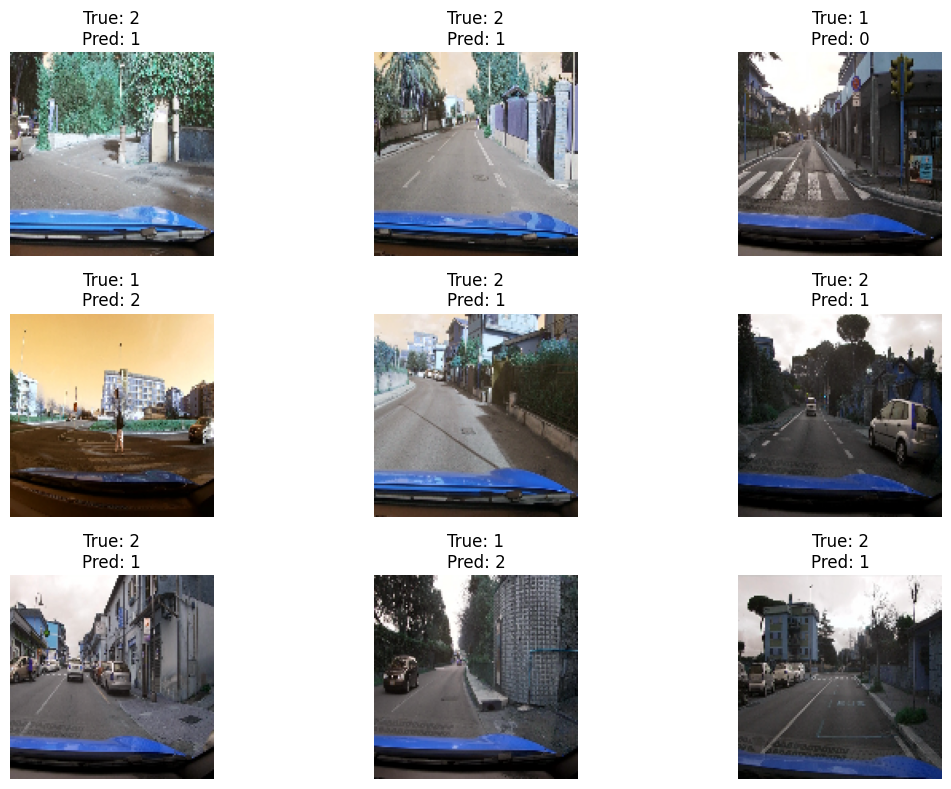

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

for i, idx in enumerate(wrong_idx[:9]):  # show first 9 mistakes

    plt.subplot(3,3,i+1)
    plt.imshow(X_test[idx])

    plt.title(
        f"True: {y_test[idx]}\nPred: {y_pred_classes[idx]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [52]:
class_names = ["pothole", "crack", "manhole"]

In [53]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def predict_image(img_path):

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # resize
    img_resized = cv2.resize(img, (128, 128))

    # normalize
    img_norm = img_resized / 255.0

    # expand dims
    img_input = np.expand_dims(img_norm, axis=0)

    # prediction
    pred = model.predict(img_input)
    class_idx = np.argmax(pred)

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predicted: {class_names[class_idx]}")
    plt.show()

    return class_names[class_idx], pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step


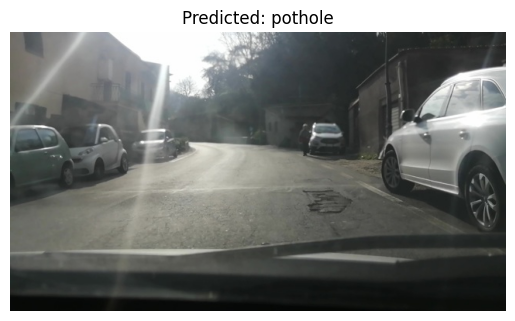

('pothole',
 array([[9.9985600e-01, 1.4391555e-04, 1.0734055e-07]], dtype=float32))

In [54]:
predict_image("/kaggle/input/road-damage-dataset-potholes-cracks-and-manholes/data/images/vlcsnap-2025-02-18-23h30m34s296.jpg")

In [55]:
model.save("road_damage_cnn.keras")

In [56]:
import json

class_names = ["pothole", "crack", "manhole"]

with open("label_map.json", "w") as f:
    json.dump(class_names, f)